## IIP314W Optimización aplicada a negocios

Soluciones análiticas vs soluciones numéricas

### Soluciones analíticas

En clases de cálculo, regularmente se nos enseñan técnicas, para encontrar soluciones analíticas a sistemas de ecuaciones, integrales, identidades, etc. En mi epoca, ya existia el software Maple, que apoyaba encontrar este tipo de soluciones, hoy existen otras como Wolfram Alpha, GeoGebra, Desmos, estas herramientas además nos apoyan en la visualización, recordar que posiblemente necesitemos acotar el espacio de decisión.

En analisis numérico, revisamos **sympy**, revisar https://www.sympy.org/en/features.html

### Soluciones numéricas

A veces hay ecuaciones como:

$$ x^9 + sin(x) - e^{-x} + \pi^x = 0 $$

Creo, que no tiene solución, ¿será razonable invertir tiempo en resolver analiticamente la ecuación?. Ahí nos salva los metodos númericos, recordar clases de metodos numéricos, donde vimos algoritmos iterativos para encontrar la solución a este tipo de ecuaciones. Algunos metodos vistos, son: bisección, falsa posición, newton-raphson, secante, gradiente descendente.

Vamos a recordar y repasar esto en ayudantía, es importante conocer el número de iteraciones, tolerancia, tiempos de ejecución para decidir cual nos conviene o comparar. Nosotros volveremos a ver uno relevante, pues es muy relevante en machine learning, donde usaremos ahora un poco de OOP.

#### Método gradiente descendente

Recordar que dijimos que en optimización, nos enfocaremos en minimización, entonces la idea es al evaluar una función, movernos hacia la dirección en que desciende la función, para ello se utiliza la derivada, en el caso de ser creciente (positivo) en un punto, debemos reducir el punto, en el caso de ser negativo, lo aumentaremos.

Si lo pensamos, necesitamos un punto de partida para aplicar este metodo iterativo, y además debemos definir cuanto nos acercaremos cada vez que iteremos a la solución y por último necesitamos definir una tolerancia para decidir cuando terminar, pues la solución podria ser irracional, por lo tanto nunca deberiamos poder llegar a ella. Adicionalmente, podria ser el caso en que nos quedemos atrapados infinitamente, necesitaremos definir un maximo numero de iteraciones.

En resumen, este metodo necesita:

- Punto inicial (starting point)
- Learning rate (cuanto nos acercaremos)
- Tolerancia (cuando nos acercamos la nada, podemos terminar)
- Maximo número de iteraciones (por si las moscas)

¿cómo los definimos?

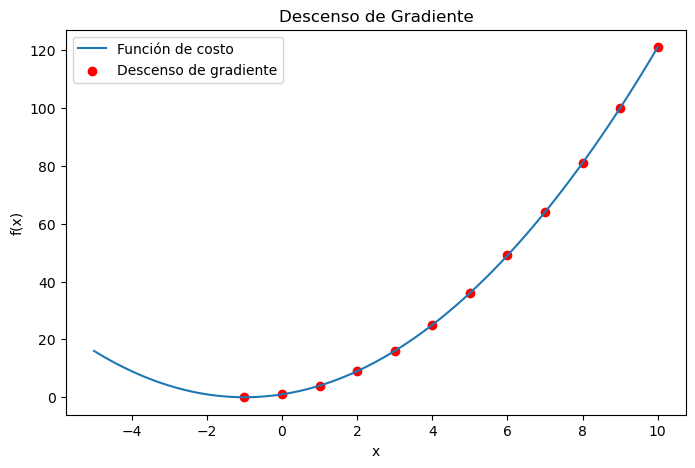

[10, 9.0, 8.0, 7.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.0, -1.0]

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 + 2*x + 1

# Derivada de la función
def df(x):
    return 2*x + 2

# Parametros Descenso de Gradiente
x = 10  # Valor inicial
learning_rate = 1
tol = 1e-5
max_iters = 100

x_history = [x]

for _ in range(max_iters):
    if np.linalg.norm(df(x))!=0:
        x = x - learning_rate * df(x)/np.linalg.norm(df(x))
    if np.abs(x-x_history[-1]) < tol:
        break
    x_history.append(x)

# Visualizar la optimización
x_vals = np.linspace(-5, 10, 100)
y_vals = f(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="Función de costo")
plt.scatter(x_history, [f(i) for i in x_history], color='red', label="Descenso de gradiente")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Descenso de Gradiente")
plt.show()
x_history

Vimos que en multivariable es como lo mismo, solo que el gradiente es un vector, por ejemplo:

$$f(x,y)=2x^2-xy+y^2-7y$$

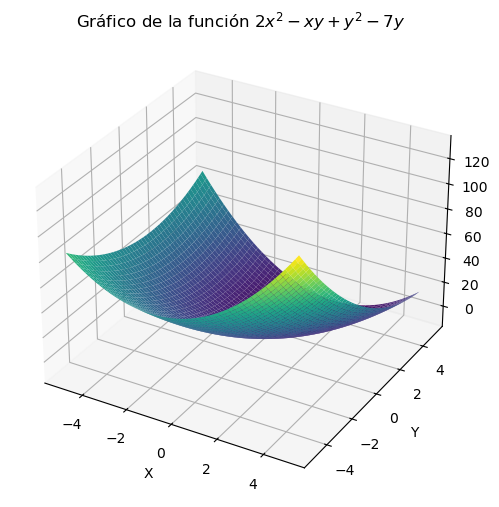

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def f(x,y):
    return 2*x**2-x*y+y**2-7*y
def gradiente(x,y):
    return np.array([4*x-y, -x+2*y-7])

x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)

# Definir la función
Z = f(X,Y) #2*X**2 - X*Y + Y**2 - 7*Y

# Crear la figura y el eje 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Graficar la superficie
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Gráfico de la función $2x^2 - xy + y^2 - 7y$')

plt.show()

In [3]:
# descenso del gradiente
def descenso_gradiente(df, X0, alpha, iteraciones=100, e=0.01):
    # in: función gradiente, punto inicial, tasa de aprendizaje, número de iteraciones, tolerancia
    # out: minimo
    X=X0
    for i in range(iteraciones):
        d=-df(X[0],X[1])/np.linalg.norm(df(X[0],X[1]))
        X=X+alpha*d
        if np.linalg.norm(df(X[0],X[1]))<e:     #criterio de parada
            break
    return X

X_start = np.array([0,0])
X_end=descenso_gradiente(gradiente, X_start, 0.1)
print("X_end =", X_end)
f(X_end[0], X_end[1])

X_end = [0.94942839 4.02094745]


-13.993386881842614

Pero, el punto optimo es (1,4) y el minimo es -14, ¿qué paso?

Implementación más bonita:

In [4]:
class GradienteDescendente:
    def __init__(self, lrate = 0.01, max_iters = 1e4, tol=1e-6, record=True):
        self.learning_rate = lrate
        self.max_iters = max_iters
        self.tolerance = tol
        self.record_history = record
        if self.record_history:
            self.history = []
 
    def run(self, gradient_fn, x, y, sol):
        grad = np.inf #lo defino infinito para entrar al while
        iteracion = 0
        while np.linalg.norm(grad) > tol and iteracion < self.max_iters:
            grad = gradient_fn(x, y, sol)
            sol = sol - self.learning_rate * grad
            if self.record_history:
                self.history.append(sol)
            iteracion += 1
        return sol

Apliquemoslo a regresion lineal, primero generemos un ejemplo:

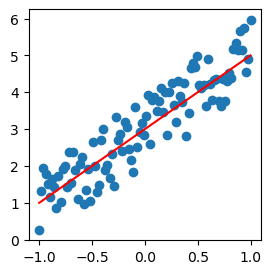

In [5]:
# Recta a+bx
a = 3
b = 2
f = lambda x: a+b*x

X_sample = np.linspace(-1, 1, 100)
Y_sample = X_sample*b + a-1 + 2*np.random.random(X_sample.shape)

Y = f(X_sample)
plt.figure(figsize=(3,3))
plt.scatter(X_sample,Y_sample)
plt.plot(X_sample,Y, color="red")
plt.show()

Ahora el modelo, que vamos a optimizar con la clase anterior. La idea es minimizar los minimos cuadrados de las diferencias entre los puntos y la recta, donde la función objetivo seria:

$$ \sum (Y_i - Y)^2 $$

In [6]:
class RegresionLineal:
    def __init__(self, bias=True):
        self.add_bias = bias # el bias es la constante del modelo
        
    def fit(self, x, y, optimizer):
        if self.add_bias:
            N = x.shape[0] # cantidad de muestras
            x = np.column_stack([x, np.ones(N)])
        N,D = x.shape
        
        # la defino adentro para que nadie la pueda ver
        def gradient(x, y, betas):
            yh = x @ betas # @ es producto de matrices
            N,D = x.shape
            grad = -2*np.dot(y-yh, x)/N
            return grad
        
        betas0 = np.zeros(D) # punto inicial
        self.betas = optimizer.run(gradient, x, y, betas0)
        return self
    
    def predict(self, x):
        if self.add_bias:
            N = x.shape[0]
            x = np.column_stack([x, np.ones(N)])
        yh = x@self.betas
        return yh

Ahora lo usamos

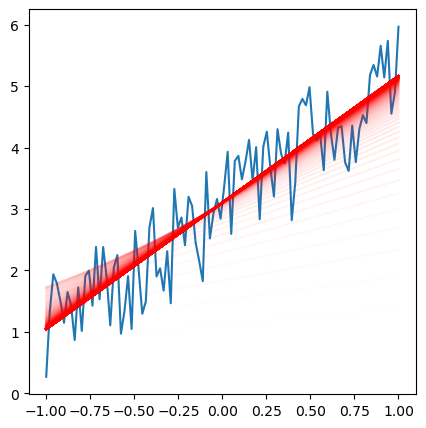

In [7]:
opt = GradienteDescendente(lrate=0.1)
modelo = RegresionLineal()
modelo.fit(X_sample, Y_sample, opt)

plt.figure(figsize=(5,5))
plt.plot(X_sample, Y_sample)
for n,h in enumerate(opt.history):
    plt.plot(X_sample, X_sample*h[0]+h[1], color="red", alpha=n/len(opt.history))

plt.show()

In [54]:
print(opt.history[-1])

[1.92721532 3.04364302]
